# **BLIP와 LLaVA**

## 1.환경준비

* 설치

In [1]:
!pip install -U "transformers>=4.40,<4.48" accelerate pillow sentencepiece einops -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 47.7 MB/s eta 0:00:00


* 라이브러리 로딩

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from transformers import pipeline
import torch
from PIL import Image

# 디바이스 준비
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 2.BLIP 사용해보기

### (1) 이미지 캡셔닝

* 이미지 → 텍스트 캡션 파이프라인 준비

In [3]:
cap_pipe = pipeline(
    task="image-to-text",
    model="Salesforce/blip-image-captioning-base",
    device=device
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

Device set to use cuda


* 테스트 파일 준비

In [4]:
from google.colab import files
uploaded = files.upload()   # 로컬 PC에서 cat_bird.jpg 선택

Saving cat_bird.jpg to cat_bird.jpg


* 이미지 캡셔닝 테스트

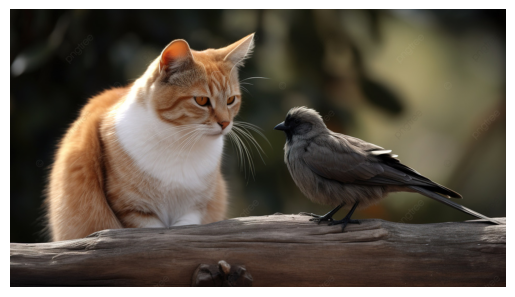

Caption: a cat and a bird are sitting on a log


In [5]:
# 테스트용 이미지 경로
img_path = "cat_bird.jpg"   # 로컬에 있는 이미지 파일로 바꿔주세요

img = Image.open(img_path).convert("RGB")
plt.imshow(img)
plt.axis("off")
plt.show()

# 캡션 생성
cap = cap_pipe(img_path, max_new_tokens=30)[0]["generated_text"]
print("Caption:", cap)

### (2) Vision QA

* 시각 질의응답 모델 파이프라인

In [6]:
vqa_pipe = pipeline(
    task="visual-question-answering",
    model="Salesforce/blip-vqa-base",
    device=device
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

Device set to use cuda


* 테스트 파일 준비

In [7]:
from google.colab import files
uploaded = files.upload()   # 로컬 PC에서 beach_children.jpg 선택

Saving beach_children.jpg to beach_children.jpg


* VQA 테스트

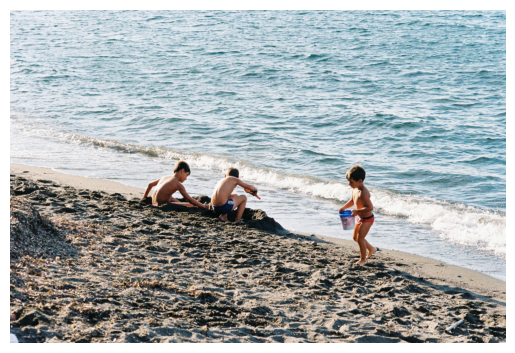

Q: What are they doing?
A: playing



In [8]:
# VQA 질문 준비
img_path = "beach_children.jpg"
questions = ["What are they doing?"]

img = Image.open(img_path).convert("RGB")
plt.imshow(img)
plt.axis("off")
plt.show()

for q in questions:
    ans = vqa_pipe(image=img_path, question=q)[0]["answer"]
    print(f"Q: {q}\nA: {ans}\n")

### (3) 실습
* 이미지를 한장 업로드해서 이미지 캡셔닝 및 VQA를 수행해 봅니다.

In [10]:
from google.colab import files
uploaded = files.upload()
img_path2 = "cat_bird.jpg"

Saving cat_bird.jpg to cat_bird (1).jpg


* 이미지 캡셔닝

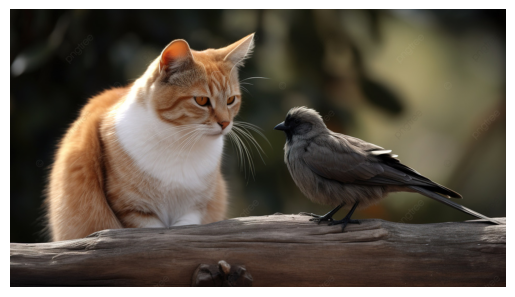

Caption: a cat and a bird are sitting on a log


In [11]:
img2 = Image.open(img_path2).convert("RGB")
plt.imshow(img2)
plt.axis("off")
plt.show()

# 캡션 생성
cap = cap_pipe(img_path2, max_new_tokens=30)[0]["generated_text"]
print("Caption:", cap)

* Vision QA

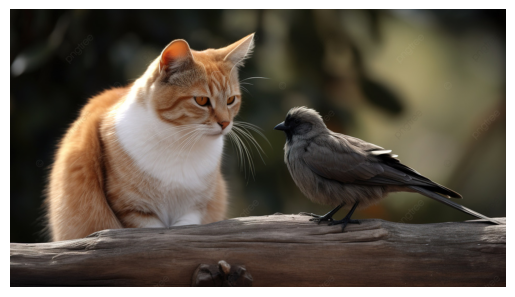

Q: What are they doing?
A: sitting



In [12]:
# VQA 질문 준비
questions = ["What are they doing?"]

plt.imshow(img2)
plt.axis("off")
plt.show()

for q in questions:
    ans = vqa_pipe(image=img_path2, question=q)[0]["answer"]
    print(f"Q: {q}\nA: {ans}\n")

## 3.LLaVA 사용해보기

* tiny-llava 모델은 pipeline 함수로 지원 안됨

### (1) 모델 다운로드

In [13]:
from transformers import AutoProcessor, LlavaForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if torch.cuda.is_available() else torch.float32

model_id = "bczhou/tiny-llava-v1-hf"

model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    low_cpu_mem_usage=True,
).to(device)

processor = AutoProcessor.from_pretrained(model_id)

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/661M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

### (2) 모델 사용

In [14]:
img = Image.open("beach_children.jpg").convert("RGB")
prompt = "USER: <image>\nWhat do you see in this picture?\nASSISTANT:"   # <image> 꼭 포함!

# 전처리 → 생성 (인자 순서 주의: text 먼저, image 다음)
inputs = processor(prompt, img, return_tensors="pt").to(device)

with torch.inference_mode():
    output_ids = model.generate(**inputs, max_new_tokens=200, do_sample=False)

# 디코딩 (프롬프트 길이만큼 잘라서 답변만 출력)
answer = processor.decode(output_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
print(answer)

You may have used the wrong order for inputs. `images` should be passed before `text`. The `images` and `text` inputs will be swapped. This behavior will be deprecated in transformers v4.47.
Expanding inputs for image tokens in LLaVa should be done in processing. Please add `patch_size` and `vision_feature_select_strategy` to the model's processing config or set directly with `processor.patch_size = {{patch_size}}` and processor.vision_feature_select_strategy = {{vision_feature_select_strategy}}`. Using processors without these attributes in the config is deprecated and will throw an error in v4.50.
Expanding inputs for image tokens in LLaVa should be done in processing. Please add `patch_size` and `vision_feature_select_strategy` to the model's processing config or set directly with `processor.patch_size = {{patch_size}}` and processor.vision_feature_select_strategy = {{vision_feature_select_strategy}}`. Using processors without these attributes in the config is deprecated and will th

The image features a group of three young boys playing on a sandy beach near the ocean. They are all standing on the beach, enjoying their time together. One of the boys is holding a frisbee, possibly preparing to throw it to another boy.

The beach is filled with various objects, such as a surfboard, a backpack, and a handbag. There are also two boats visible in the water, one closer to the left side of the scene and the other further away on the right side. The scene captures a fun and lively atmosphere as the boys engage in their playtime on the beach.


### (3) 실습
* BLIP 실습에서 업로드한 이미지를 사용합니다.
* VQA를 위한 프롬프트를 작성하여 결과를 확인해 봅시다.

In [15]:
prompt = "USER: <image>\nWhat do you see in this picture?\nASSISTANT:"

inputs = processor(prompt, img2, return_tensors="pt").to(device)

with torch.inference_mode():
    output_ids = model.generate(**inputs, max_new_tokens=200, do_sample=False)

answer = processor.decode(output_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
print(answer)

The image features a cat sitting on a wooden log, looking at a bird perched on the same log. The cat appears to be staring at the bird, possibly curious about its presence. The bird is perched on the log near the cat, with its wings spread out.

The scene is set in a natural environment, with the cat and the bird both resting on the log. The bird is situated towards the right side of the image, while the cat is positioned towards the left side.


## 4.BLIP와 LLaVA 비교

### (1) 테스트 이미지와 질문 준비

In [16]:
# 이미 업로드한 파일 사용
img_path = "beach_children.jpg"
img = Image.open(img_path).convert("RGB")
questions = ["What is in the image?", "How many people are there?", "Describe the scene."]

### (2) 두 모델 비교

In [17]:
#  BLIP 실행
print("=== BLIP (Salesforce/blip-vqa-base) ===================")
for q in questions:
    ans = vqa_pipe(img, q, max_new_tokens=32)[0]["answer"]
    print(f"Q: {q}\nA: {ans}\n")

#  LLaVA 실행
print("=== LLaVA (bczhou/tiny-llava-v1-hf) ===================")
for q in questions:
    prompt = f"USER: <image>\n{q}\nASSISTANT:"
    inputs = processor(prompt, img, return_tensors="pt").to(
        device,
        torch.float16 if torch.cuda.is_available() else torch.float32
    )
    with torch.inference_mode():
        out_ids = model.generate(**inputs, max_new_tokens=128, do_sample=False)
    answer = processor.decode(out_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    print(f"Q: {q}\nA: {answer}\n")

=== BLIP (Salesforce/blip-vqa-base) ===================
Q: What is in the image?
A: beach

Q: How many people are there?
A: four

Q: Describe the scene.
A: beach

=== LLaVA (bczhou/tiny-llava-v1-hf) ===================
Q: What is in the image?
A: The image features a group of three young boys playing on a beach, with one of them holding a frisbee.

Q: How many people are there?
A: There are three people in the image.

Q: Describe the scene.
A: The image depicts a group of three young boys playing on a sandy beach near the ocean. They are enjoying themselves, with one boy standing on the beach and two others nearby. The boys are scattered across the scene, with one boy closer to the left side, another in the middle, and the third one on the right side.

The beach is lined with rocks, adding to the natural scenery. The boys are playing with a frisbee, which can be seen in the middle of the scene. The overall atmosphere of the image is lively and fun, with the boys having a great time



### (3) 실습
새로운 이미지를 찾아서 비교해 봅시다

* 이미지 업로드 및 저장

Saving cat_bird.jpg to cat_bird (2).jpg


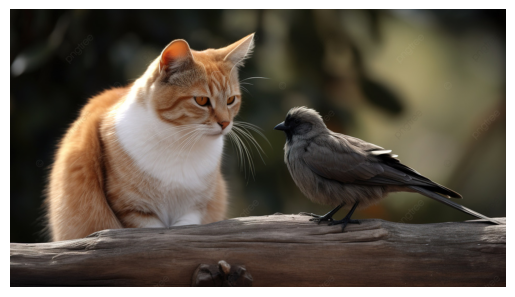

In [18]:
from google.colab import files
uploaded = files.upload()   # 로컬 PC에서 cat_bird.jpg 선택

img_path = "cat_bird.jpg"
img = Image.open(img_path).convert("RGB")
plt.imshow(img)
plt.axis("off")
plt.show()

* 테스트 질문 저장

In [19]:
questions = ["What is in the image?", "How many people are there?", "Describe the scene."]

* 모델 비교

In [20]:
#  BLIP 실행
print("=== BLIP (Salesforce/blip-vqa-base) ===================")
for q in questions:
    ans = vqa_pipe(img, q, max_new_tokens=32)[0]["answer"]
    print(f"Q: {q}\nA: {ans}\n")

#  LLaVA 실행
print("=== LLaVA (bczhou/tiny-llava-v1-hf) ===================")
for q in questions:
    prompt = f"USER: <image>\n{q}\nASSISTANT:"
    inputs = processor(prompt, img, return_tensors="pt").to(
        device,
        torch.float16 if torch.cuda.is_available() else torch.float32
    )
    with torch.inference_mode():
        out_ids = model.generate(**inputs, max_new_tokens=128, do_sample=False)
    answer = processor.decode(out_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    print(f"Q: {q}\nA: {answer}\n")

=== BLIP (Salesforce/blip-vqa-base) ===================
Q: What is in the image?
A: cat and bird

Q: How many people are there?
A: none

Q: Describe the scene.
A: outdoor

=== LLaVA (bczhou/tiny-llava-v1-hf) ===================
Q: What is in the image?
A: The image features a cat sitting on a wooden log, looking at a bird. The cat is sitting on the log, while the bird is perched on the opposite end of the log.

Q: How many people are there?
A: There are two people in the image.

Q: Describe the scene.
A: The image features a cat sitting on a wooden log, looking at a bird perched on the same log. The cat appears to be staring at the bird, possibly curious about its presence. The bird is perched on the log near the cat, with its wings spread out.

The scene is set in a natural environment, with the bird and the cat both resting on the log. The bird is situated towards the right side of the image, while the cat is on the left side.

